# Interpretation of model results


<Axes: xlabel='Number_of_Priors'>

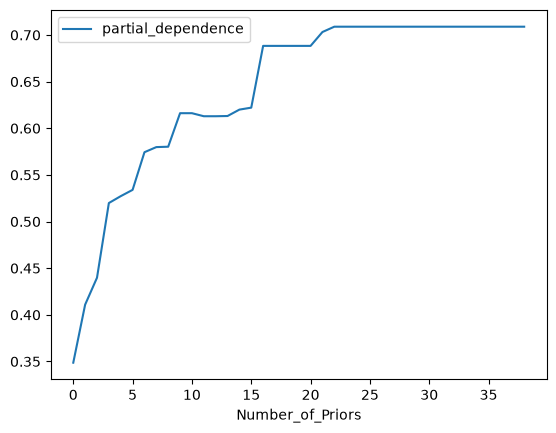

In [1]:
# Run with the notebook's working directory = xgboost/ (so xgb_model / interpret import).
# compas_scoring itself is installed in the project venv, so no sys.path hacks are needed.
from xgb_model import load_data, load_model
from interpret import pdp_data

train, test = load_data("race_aware")
model = load_model("race_aware")

pdp = pdp_data(model, test, features=["Number_of_Priors", "Age_Above_FourtyFive"])

# pdp is a dict: {feature_name: DataFrame with [feature, "partial_dependence"]}
pdp["Number_of_Priors"].plot(x="Number_of_Priors", y="partial_dependence")

<Axes: >

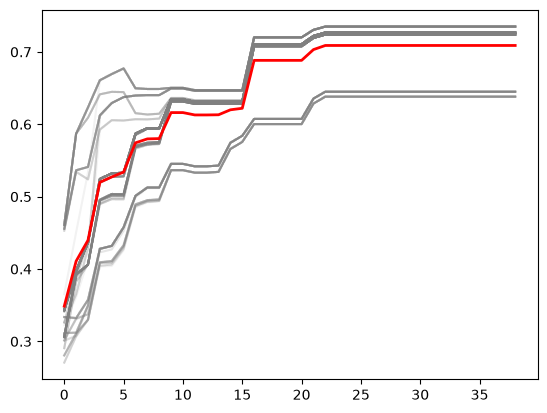

In [2]:
from interpret import ice_data
ice = ice_data(model, test, "Number_of_Priors")      # rows = people, columns = grid values
ax = ice.sample(200, random_state=0).T.plot(legend=False, alpha=0.1, color="grey")
ice.mean().plot(ax=ax, color="red", lw=2)            # the mean of the ICE curves is the PDP


In [3]:
from interpret import lime_explanation
person = test.X.iloc[0]
lime_explanation(model, train, person)


,rule,weight
0,Number_of_Priors <= 0.00,-0.152061
1,Age_Below_TwentyFive <= 0.00,-0.110484
2,Age_Above_FourtyFive <= 0.00,0.053751
3,Female <= 0.00,0.021889
4,Native_American <= 0.00,-0.021877
5,Asian <= 0.00,-0.021319
6,0.00 < Misdemeanor <= 1.00,-0.012767
7,African_American <= 0.00,-0.004473
8,Hispanic <= 0.00,0.003176
9,Other > 0.00,-0.000245


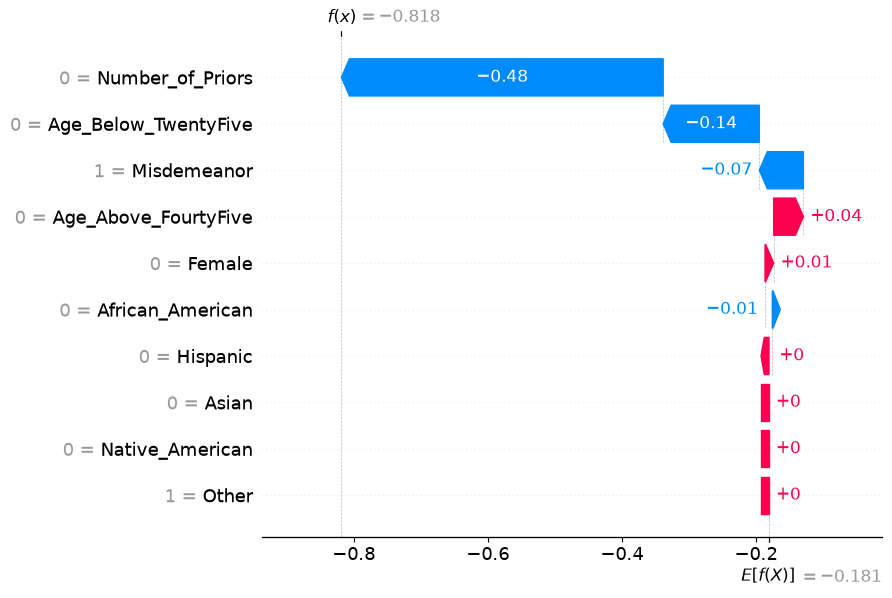

In [6]:
import shap
from interpret import shap_values

vals, expl = shap_values(model, test)
shap.plots.waterfall(expl[0])



In [5]:
from interpret import load_interpretability
marginal, impurity, shap_df = load_interpretability("race_aware")


<Axes: title={'center': 'LIME (20 runs) — model P(recidivism) = 0.31'}, ylabel='rule'>

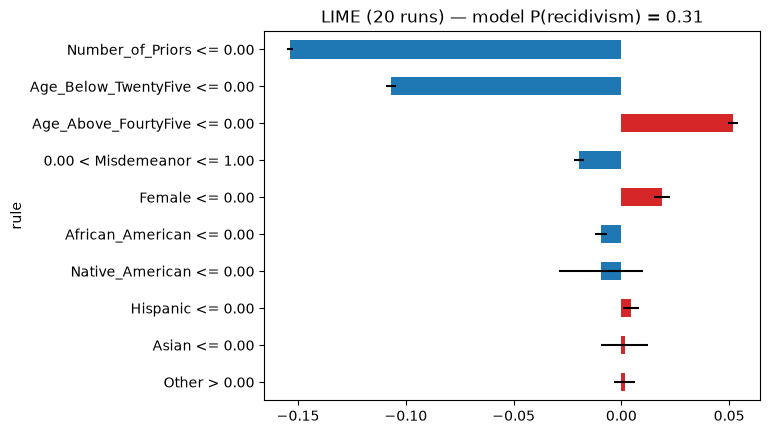

In [7]:
import pandas as pd
from interpret import lime_explanation

person = test.X.iloc[0]
runs = pd.concat(
    [lime_explanation(model, train, person).set_index("rule")["weight"] for _ in range(20)],
    axis=1,
)
stability = pd.DataFrame({"mean": runs.mean(axis=1), "std": runs.std(axis=1)})
stability = stability.reindex(stability["mean"].abs().sort_values().index)

# Bars in red push risk up, blue push it down; error bars show run-to-run spread
stability["mean"].plot.barh(
    xerr=stability["std"],
    color=["tab:red" if w > 0 else "tab:blue" for w in stability["mean"]],
    title=f"LIME (20 runs) — model P(recidivism) = {model.predict_proba(test.X.iloc[[0]])[0, 1]:.2f}",
)


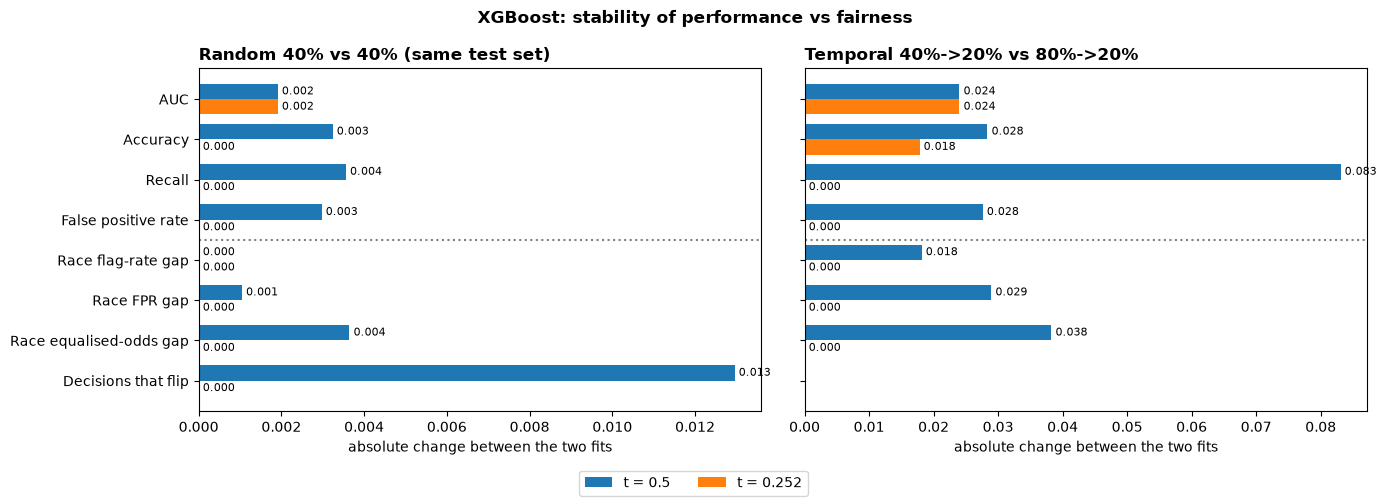

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from stability import stability_deltas

deltas = stability_deltas("race_aware")
metrics = list(dict.fromkeys(deltas["metric"]))
points = list(dict.fromkeys(deltas["operating_point"]))
designs = list(dict.fromkeys(deltas["design"]))

fig, axes = plt.subplots(1, len(designs), figsize=(14, 5), sharey=True)
y = np.arange(len(metrics))
for ax, design in zip(axes, designs):
    sub = deltas[deltas["design"] == design]
    for k, point in enumerate(points):
        vals = sub[sub["operating_point"] == point].set_index("metric")["abs_delta"].reindex(metrics)
        bars = ax.barh(y + (k - 0.5) * 0.38, vals, height=0.38, label=point)
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.axhline(3.5, ls=":", color="grey")  # performance above the line, fairness below
    ax.set_title(design, loc="left", fontweight="bold")
    ax.set_xlabel("absolute change between the two fits")
axes[0].set_yticks(y, metrics)
axes[0].invert_yaxis()
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=2)
fig.suptitle("XGBoost: stability of performance vs fairness", fontweight="bold")
fig.tight_layout(rect=(0, 0.06, 1, 1))


## Global importance: impurity and marginal effects

Both tables come from `python interpret.py` (saved in `models/`), computed on the saved race-aware model:

- **Impurity importance**, read straight from the trees. `weight` is how many splits use a feature, `gain` is the average loss reduction per split, and `cover` is the average number of defendants those splits touch.
- **Marginal effect**, the average change in P(recidivism) when a feature changes, holding the others fixed. Binary features are switched from 0 to 1.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from compas_scoring.config import CONFIG
from xgb_model import MODEL_DIR

features = CONFIG.features("race_aware")
impurity = pd.read_csv(MODEL_DIR / "interp_race_aware_impurity.csv", index_col=0)
marginal = pd.read_csv(MODEL_DIR / "interp_race_aware_marginal.csv", index_col=0)["marginal_effect"]

# XGBoost only reports features it split on; a feature missing from the table was never used.
never_used = [f for f in features if f not in impurity.index]
print("Features the model never splits on:", never_used)
print("Training rows with each:", train.X[never_used].sum().astype(int).to_dict())

impurity = impurity.reindex(features).fillna(0.0)
# gain is an AVERAGE per split; weight x gain is the feature's TOTAL contribution to the fit.
impurity["total_gain"] = impurity["weight"] * impurity["gain"]
shares = (impurity / impurity.sum() * 100).sort_values("total_gain", ascending=False)
shares.round(1)

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
titles = {
    "total_gain": "Total gain (weight x gain)",
    "gain": "Average gain per split",
    "weight": "Number of splits",
    "cover": "Average defendants per split",
}
for ax, (col, title) in zip(axes, titles.items()):
    shares[col].plot.barh(ax=ax, color="tab:blue")
    ax.set_title(title)
    ax.set_xlabel("% of total")
axes[0].invert_yaxis()
fig.suptitle("XGBoost impurity importance, race-aware model (share of each measure)", fontweight="bold")
fig.tight_layout()

**What the impurity table says**

- **Priors and age drive the model.** By total gain, `Number_of_Priors` accounts for **66.5%** of what the trees learn and `Age_Below_TwentyFive` for **19.5%**, so these two account for 86%. Every other feature is under 7%.
- **Age under 25 is used rarely but decisively.** It has 13% of the splits but 32% of the average gain, the highest gain per split after priors, and the highest cover. When the model uses it, the split is near the top of the tree and affects many defendants.
- **Age over 45 is the opposite:** 19% of the splits but only 7% of the gain. The model uses it often, for small late adjustments.
- **Race: African-American is used often but for little.** It has 10% of the splits (144 splits, more than `Female` or `Misdemeanor`), but only 1.8% of total gain and the lowest cover (about 65 defendants per split). The model uses race in many small, deep splits that fine-tune predictions for small subgroups. It is a minor driver, but not a zero one.
- **Asian, Native American and Other are never used.** They have no splits, so they have no effect on any prediction. For Asian (20 training rows) and Native American (9), the groups are too small to split on. `Other` has 246 rows and is still never chosen: it adds nothing beyond the other features.
- **Hispanic** has only 17 splits but a high cover (17%). These are shallow splits that affect many people, with a small total effect (0.3%).

In [ ]:
from interpret import pdp_data

binary = marginal.drop("Number_of_Priors").sort_values()
ax = binary.mul(100).plot.barh(
    color=["tab:red" if v > 0 else "tab:blue" for v in binary], figsize=(7, 4)
)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("change in P(recidivism), percentage points (feature 0 -> 1)")
ax.set_title("Marginal effects of the binary features")

# Number_of_Priors is left out: its saved value (see below) is an artifact, so use the PDP slope.
pdp_priors = pdp_data(model, test, features=["Number_of_Priors"])["Number_of_Priors"]
p = pdp_priors.set_index("Number_of_Priors")["partial_dependence"]
print(f"Saved marginal effect for priors: {marginal['Number_of_Priors']:.3f}  (not usable, see note)")
print(f"PDP: 0 priors -> {p.loc[0]:.3f}, 1 -> {p.loc[1]:.3f}, 3 -> {p.loc[3]:.3f}, 10 -> {p.loc[10]:.3f}, max -> {p.max():.3f}")
print(f"Average slope from 0 to 10 priors: {(p.loc[10] - p.loc[0]) / 10 * 100:.1f} points per prior")

**What the marginal effects say**

- **Age dominates the binary features.** Being under 25 raises the predicted risk by **+10.7 points** and being over 45 lowers it by **-5.2 points**, compared with a 25-45 year-old with the same record.
- **Sex and charge degree matter less.** Being female lowers risk by -2.4 points and a misdemeanour (instead of a felony) by -1.8.
- **Race: being African-American raises predicted risk by +1.1 points** with everything else held fixed. That is small, but it is a direct effect of race on the score, and it matches the impurity table (race is used, just not much). Hispanic is -0.4 points. Asian, Native American and Other are exactly 0 because the model never splits on them.
- **The saved value for priors (2.48) should not be read as an effect.** It would mean +248 points per prior. XGBoost's predictions are step functions, and this measure nudges priors by a tiny amount. When a nudge crosses a split threshold, dividing by that tiny amount blows the number up. The PDP gives the real effect: risk rises from **35% at 0 priors to about 61% at 10**, around **+2.7 points per prior**. The rise is steepest over the first few priors, then flattens.

In [ ]:
# Do the measures agree on the ranking? (1 = most important)
ranks = pd.DataFrame({
    "total_gain": impurity["total_gain"],
    "gain": impurity["gain"],
    "weight": impurity["weight"],
    "cover": impurity["cover"],
    "|marginal effect|": marginal.abs().drop("Number_of_Priors"),
}).rank(ascending=False, method="min")
display(ranks.sort_values("total_gain"))
ranks.corr("spearman").round(2)

**Do the two methods agree?**

Mostly, yes. Total gain and the absolute marginal effect rank the binary features identically (Spearman 1.00), and average gain nearly so (0.97). Total gain and average gain put priors first and age under 25 second. Cover swaps them, and the split count puts age over 45 second, because it is used in many small splits. Cover agrees least with the others (0.73-0.86) because it counts how many people a split touches, not how much it changes their prediction. Hispanic ranks 3rd on cover and 6th-7th on everything else.

**Takeaways for the report**

1. The model is, in effect, a **priors + age** model: 86% of the total gain.
2. **Race has a small but non-zero direct effect** (about +1 point for African-American defendants, 10% of splits, 1.8% of gain). A race-blind model removes this direct effect, but priors, which is correlated with race, still carries race information indirectly.
3. **Groups with little data are ignored** (Asian, Native American, Other): the model has no information to base a different prediction on.
4. Report **total gain**, not XGBoost's default average gain, which makes rarely used features look important, and use the **PDP** rather than the finite-difference marginal effect for priors.